<img src="https://raw.githubusercontent.com/Brainchip-Inc/brainchip_devhub/main/docs/assets/0.-BC-dev-hub-LOGO-flicker.svg" alt="BrainChip Dev Hub" width="200"/>

# Inducing Activation Sparsity in Visual Wake Words (Akida 1)

<p align="right">
Run Time: ~10 minutes (no retraining) / hours if you set RUN_SWEEP = True
</p>

Akida is an event-driven architecture: compute scales with the number of
**non-zero activations**, not tensor size. Activation sparsity is therefore
not just a curiosity, it directly determines inference latency and power.
This notebook is entirely focused on that lever, applied to the **Visual
Wake Words (VWW)** binary classifier already covered in the neighbouring
[`vww_notebook_training.ipynb`](../../model_zoo/vww/vww_notebook_training.ipynb)
and [`vww_notebook_benchmark.ipynb`](../../model_zoo/vww/vww_notebook_benchmark.ipynb)
— see those for the full training/quantization/conversion walkthrough, and
[`SPARSITY_EXPERIMENT.md`](../../model_zoo/vww/SPARSITY_EXPERIMENT.md) in that
same folder for the complete experiment log this notebook summarizes.

We cover, in order:
1. How activation sparsity is induced during training (an `activity_regularizer`
   on every ReLU layer) using two regularizer types: **L1L2** and a
   scale-invariant **normalized Hoyer-Square** penalty.
2. The resulting **accuracy vs. sparsity** trade-off, swept across
   regularization strengths for both regularizer types.
3. **Per-layer** sparsity — where in the network the gains actually land.
4. **Benchmarking** — how those sparsity gains translate into measured
   latency and power on AKD1500 hardware.

Colab-only setup. Local users: ignore this cell — it does nothing for you.

In [1]:
import sys, os

if 'google.colab' in sys.modules:
    if not os.path.exists('colab_setup.py'):
        get_ipython().system('wget -q https://raw.githubusercontent.com/Brainchip-Inc/brainchip_devhub/main/akida1/tutorials/vww_sparsity/colab_setup.py')
    import colab_setup; colab_setup.setup()

## Setup

This tutorial reuses the vww/ example's training, data-loading and
evaluation code unmodified (`vww_data.py`, `vww_model.py`, `vww_train.py`,
`vww_sparsity_sweep.py`) rather than copying it — we just add that folder to
`sys.path`. `data/` here is a symlink to the vww/ example's own dataset copy
to avoid a second ~650MB download; see that example's
[README](../../model_zoo/vww/README.md#dataset-setup) if you need to fetch
it fresh.

In [2]:
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '1')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

VWW_DIR = os.path.abspath('../../model_zoo/vww')
sys.path.insert(0, VWW_DIR)

DATA_PATH = './data/vw_coco2014_96'
RESULTS_DIR = './results'
DOCS_DIR = './docs'
INPUT_SHAPE = (96, 96, 3)
SEED = 42

tf.config.experimental.enable_op_determinism()

2026-09-09 16:44:11.033547: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788997451.050485 3019725 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788997451.055452 3019725 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788997451.068591 3019725 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788997451.068609 3019725 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788997451.068611 3019725 computation_placer.cc:177] computation placer alr

## Recap: model & baseline

The model is a standard AkidaNet (alpha=0.25, 96x96 input, 226,906 params),
trained through the usual float -> quantize -> QAT -> convert pipeline (see
the training notebook for details). The published baseline, measured on real
AKD1500 hardware:

In [3]:
with open(os.path.join(VWW_DIR, 'docs', 'metrics.json')) as f:
    baseline_metrics = json.load(f)

print(f"Float acc:  {baseline_metrics['float_acc']}")
print(f"QAT acc:    {baseline_metrics['qat_acc']}")
print(f"Akida acc:  {baseline_metrics['akida_acc']}")
print(f"Sparsity:   {baseline_metrics['sparsity']} (hardware-measured)")

Float acc:  89.33%
QAT acc:    88.54%
Akida acc:  88.42%
Sparsity:   68.29% (hardware-measured)


**Note on sparsity numbers below:** the sweep in this notebook measures
sparsity with the *software* backend (`akida_models.sparsity.compute_sparsity`,
no hardware `.map()` call), since the sweep was run on a machine with no
AKD1500 attached. That measures a baseline of **52.4%**, not the **68.29%**
above — the two backends aren't bit-exact on activation zero/non-zero
decisions, even though they agree on final accuracy. The sweep's numbers are
internally consistent (safe to compare against each other) but not directly
against the hardware-measured 68.29% baseline. Full root-cause writeup in
`SPARSITY_EXPERIMENT.md`.

## Inducing sparsity: activity regularization on ReLU layers

`vww_train.py` accepts `-reg <value> --reg-type {l1l2,hoyer_square,hoyer_square_norm}`,
which attaches an `activity_regularizer` to every `ReLU` layer in the model
— applied at *both* the float-training and QAT stages, so the induced
sparsity survives quantization. Two regularizer types are compared here:

- **L1L2** (`tf_keras.regularizers.L1L2`) — standard uniform shrinkage of
  activation magnitudes.
- **Normalized Hoyer-Square** — `factor * (sum|x|)^2 / sum(x^2) / n`, a
  scale-invariant sparsity-inducing penalty (Yang, Wen & Li, *DeepHoyer*,
  ICLR 2020). Minimizing this ratio favors a few large activations over many
  small ones, for the same L1 norm. Dividing by the element count `n` keeps
  the penalty in `(0, 1]` regardless of layer size — this model's 14 ReLU
  layers range from 256 to 36,864 elements (~144x), and without the `/n`
  term a single fixed `factor` puts wildly uneven pressure across that
  range (raw values 3,022 to 560,892 on one batch — see
  `SPARSITY_EXPERIMENT.md` for the calibration diagnostic).

In [4]:
import inspect
from vww_train import HoyerSquare

print(inspect.getsource(HoyerSquare))

class HoyerSquare(regularizers.Regularizer):
    """Hoyer-Square activity regularizer: factor * (sum|x|)^2 / sum(x^2).

    Scale-invariant sparsity-inducing penalty (Yang, Wen & Li, "DeepHoyer",
    ICLR 2020). Unlike L1/L2, minimizing this ratio pushes activations toward a
    sparse (few large, rest ~zero) configuration rather than uniformly shrinking
    every value -- a large-but-sparse activation and a small-but-dense one can
    have the same L1 norm, but the sparse one has a lower Hoyer-Square value.

    Raw form is unbounded: for a tensor of N elements the ratio ranges up to N
    itself (dense/uniform case), so the same `factor` exerts more pressure on
    layers with more elements. With `normalize=True`, divides by N so the
    penalty is bounded in (0, 1] regardless of tensor size -- a prior
    unrelated project (DPLS) found this normalization is what prevents
    DeepHoyer from collapsing training (raw penalty on one activation batch
    measured ~797,000 vs ~0.5 normali

## The sweep

[`vww_sparsity_sweep.py`](../../model_zoo/vww/vww_sparsity_sweep.py) runs the
full pipeline (float train -> eval -> quantize -> QAT -> eval -> convert ->
Akida eval -> sparsity) once per regularization value, e.g.:
```bash
cd ../../model_zoo/vww
python vww_sparsity_sweep.py --reg-type l1l2 \
    --reg-values 0 1e-7 1e-6 1e-5 1e-3 --float-epochs 20 --qat-epochs 5 \
    --out-dir sweep_results
python vww_sparsity_sweep.py --reg-type hoyer_square_norm \
    --reg-values 0.036 0.36 3.6 --float-epochs 20 --qat-epochs 5 \
    --out-dir sweep_results_hoyer_norm
```
Each point is a full retrain (~1-2 hours/point on a modern GPU), so this
notebook loads the precomputed `sweep_summary.csv` files under `./results/`
by default rather than re-running it. Flip the flag below if you have a GPU
and time to spare.

In [5]:
RUN_SWEEP = False  # True re-runs the sweep from scratch (hours) instead of loading ./results/*.csv

if RUN_SWEEP:
    os.makedirs(RESULTS_DIR, exist_ok=True)
    get_ipython().system(
        f'cd {VWW_DIR} && python vww_sparsity_sweep.py --reg-type l1l2 '
        f'--reg-values 0 1e-7 1e-6 1e-5 1e-3 --float-epochs 20 --qat-epochs 5 '
        f'--out-dir {os.path.abspath(RESULTS_DIR)}/sweep_l1l2'
    )
    get_ipython().system(
        f'cd {VWW_DIR} && python vww_sparsity_sweep.py --reg-type hoyer_square_norm '
        f'--reg-values 0.036 0.36 3.6 --float-epochs 20 --qat-epochs 5 '
        f'--out-dir {os.path.abspath(RESULTS_DIR)}/sweep_hoyer_norm'
    )
else:
    print(f'RUN_SWEEP is False -- loading precomputed results from {RESULTS_DIR}/*.csv')

RUN_SWEEP is False -- loading precomputed results from ./results/*.csv


## Accuracy vs. sparsity

Reg values aren't directly comparable between L1L2 and Hoyer-Square (their
formulas operate on different scales), so we plot accuracy against
*measured sparsity* instead — that's the axis that's actually comparable,
and the one that matters for the trade-off.

In [6]:
l1l2 = pd.concat([
    pd.read_csv(f'{RESULTS_DIR}/l1l2_pass1_coarse.csv'),
    pd.read_csv(f'{RESULTS_DIR}/l1l2_pass2_finer.csv'),
    pd.read_csv(f'{RESULTS_DIR}/l1l2_pass3_knee.csv'),
], ignore_index=True)
# pass2 re-tested reg=1e-5 with 10 QAT epochs (vs. 5 elsewhere) to check
# whether the QAT-stage collapse there was an epoch-budget problem -- it
# wasn't (see SPARSITY_EXPERIMENT.md, Pass 2). Keep the 5-epoch value (from
# pass1) for the main curve so every point uses the same QAT budget.
l1l2 = l1l2.sort_values('reg', kind='stable').drop_duplicates(subset='reg', keep='first')
l1l2['reg_type'] = 'l1l2'

hoyer_norm = pd.read_csv(f'{RESULTS_DIR}/hoyer_square_norm_pass5.csv').sort_values('reg')

sweep = pd.concat([l1l2, hoyer_norm], ignore_index=True)
sweep[['reg_type', 'reg', 'sparsity', 'float_accuracy', 'qat_accuracy', 'akida_accuracy']]

,reg_type,reg,sparsity,float_accuracy,qat_accuracy,akida_accuracy
0,l1l2,0.000000e+00,0.5238,0.8918,0.8827,0.8847
1,l1l2,1.000000e-07,0.5554,0.8930,0.8849,0.8817
2,l1l2,1.000000e-06,0.6583,0.8840,0.8536,0.8536
3,l1l2,2.000000e-06,0.7101,0.8772,0.8063,0.8066
4,l1l2,3.000000e-06,0.7236,0.8744,0.7649,0.7647
5,l1l2,5.000000e-06,0.7919,0.8651,0.6748,0.6717
6,l1l2,1.000000e-05,0.7773,0.8532,0.6775,0.6675
7,l1l2,1.000000e-03,1.0000,0.5152,0.5152,0.5152
8,hoyer_square_norm,3.600000e-02,0.5266,0.8911,0.8837,0.8820
9,hoyer_square_norm,3.600000e-01,0.5546,0.8882,0.8765,0.8778


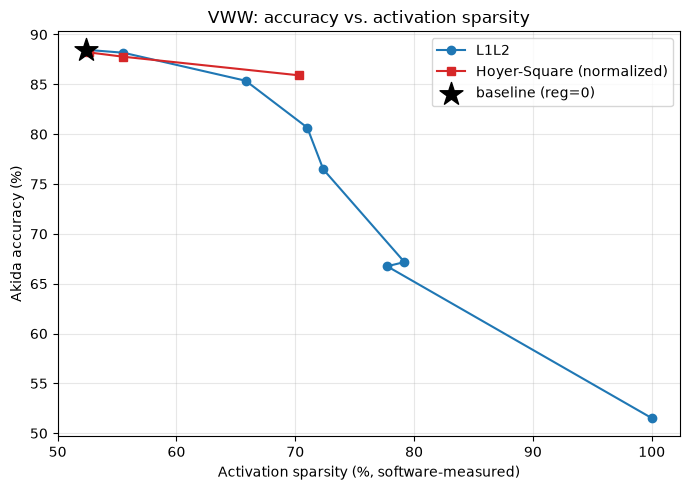

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for df, label, color, marker in [
    (l1l2, 'L1L2', '#1f77b4', 'o'),
    (hoyer_norm, 'Hoyer-Square (normalized)', '#d62728', 's'),
]:
    ax.plot(df['sparsity'] * 100, df['akida_accuracy'] * 100, marker=marker, color=color,
            label=label, linewidth=1.5)

baseline = l1l2[l1l2['reg'] == 0].iloc[0]
ax.scatter([baseline['sparsity'] * 100], [baseline['akida_accuracy'] * 100],
           marker='*', s=300, color='black', zorder=5, label='baseline (reg=0)')

ax.set_xlabel('Activation sparsity (%, software-measured)')
ax.set_ylabel('Akida accuracy (%)')
ax.set_title('VWW: accuracy vs. activation sparsity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs(DOCS_DIR, exist_ok=True)
plt.savefig(f'{DOCS_DIR}/accuracy_vs_sparsity.png', dpi=150)
plt.show()

At matched sparsity, normalized Hoyer-Square strictly dominates L1L2 across
this whole sweep: L1L2 declines smoothly then falls off a cliff past
`reg=1e-6` (67% accuracy by `reg=5e-6`, essentially the majority-class floor
by `reg=1e-5`), while Hoyer-Square-normalized stays well-behaved out to its
strongest tested point. The best trade-off found across the entire
experiment is **normalized Hoyer-Square at `reg=3.6`: 70.4% sparsity for a
2.6pt accuracy cost** (88.47% -> 85.90% Akida accuracy) — more sparsity
*and* less accuracy cost than L1L2's own best point (`reg=1e-6`: 65.8%
sparsity, ~3.1pt cost). See `SPARSITY_EXPERIMENT.md` for the full pass-by-pass
breakdown, including the calibration diagnostic used to pick comparable reg
values between the two regularizer types.

## Per-layer sparsity

Mean sparsity hides *where* the gains land. Below we compare per-layer
activation sparsity (via `akida_models.sparsity.compute_sparsity`, same
software backend as the sweep) for three checkpoints: the baseline, L1L2's
best point (`reg=1e-6`), and normalized Hoyer-Square's best point
(`reg=3.6`).

In [8]:
RUN_PER_LAYER_LIVE = False  # True recomputes from the sweep's .fbz checkpoints (not committed -- run the sweep first)

PER_LAYER_MODELS = {
    'baseline': f'{VWW_DIR}/pretrained_models/akidanet_vww_qat.fbz',
    'l1l2_reg1e-6': f'{VWW_DIR}/sweep_results_finer/reg_1e-06/akidanet_vww_qat.fbz',
    'hoyer_norm_reg3.6': f'{VWW_DIR}/sweep_results_hoyer_norm/hoyer_square_norm_reg_4e+00/akidanet_vww_qat.fbz',
}

if RUN_PER_LAYER_LIVE and all(os.path.exists(p) for p in PER_LAYER_MODELS.values()):
    import akida
    from akida_models.sparsity import compute_sparsity
    from vww_data import get_samples

    samples = get_samples(DATA_PATH, INPUT_SHAPE, num_samples=1024)
    per_layer = {}
    for tag, path in PER_LAYER_MODELS.items():
        sp = compute_sparsity(akida.Model(path), samples=samples, batch_size=1024)
        per_layer[tag] = {k: float(v) for k, v in sp.items()}
    with open(f'{RESULTS_DIR}/per_layer_sparsity.json', 'w') as f:
        json.dump(per_layer, f, indent=2)
else:
    with open(f'{RESULTS_DIR}/per_layer_sparsity.json') as f:
        per_layer = json.load(f)

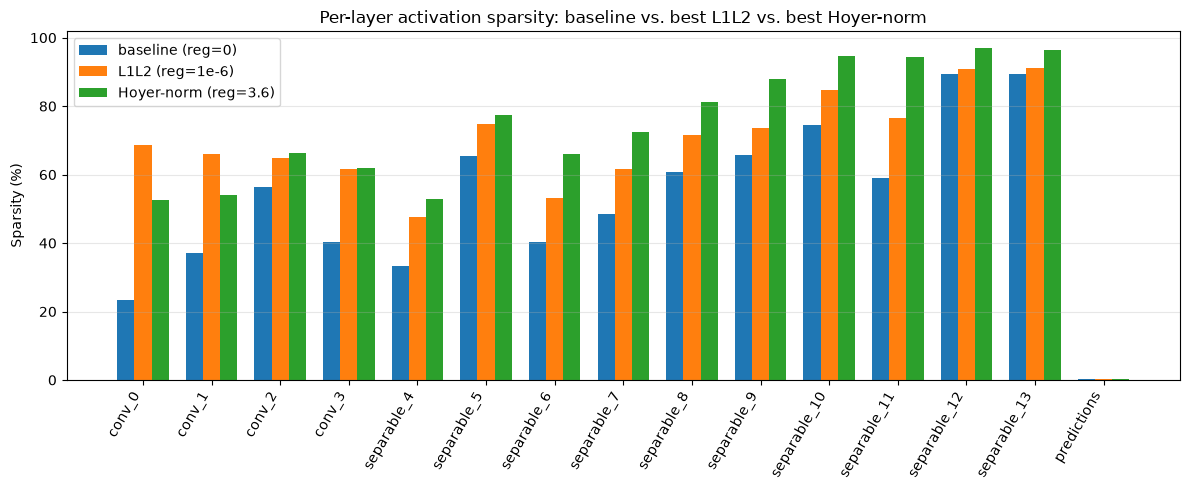

In [9]:
layers = list(per_layer['baseline'].keys())
x = np.arange(len(layers))
width = 0.25
labels = {'baseline': 'baseline (reg=0)', 'l1l2_reg1e-6': 'L1L2 (reg=1e-6)',
          'hoyer_norm_reg3.6': 'Hoyer-norm (reg=3.6)'}

fig, ax = plt.subplots(figsize=(12, 5))
for i, (tag, label) in enumerate(labels.items()):
    vals = [per_layer[tag][layer] * 100 for layer in layers]
    ax.bar(x + (i - 1) * width, vals, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(layers, rotation=60, ha='right')
ax.set_ylabel('Sparsity (%)')
ax.set_title('Per-layer activation sparsity: baseline vs. best L1L2 vs. best Hoyer-norm')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DOCS_DIR}/per_layer_sparsity.png', dpi=150)
plt.show()

Both regularizers push every layer sparser than baseline, but unevenly —
the early layers (`conv_0`, `conv_1`), which start out *least* sparse at
baseline, gain the most in absolute terms (`conv_0`: 23% -> 69% under
L1L2). The deepest `separable` layers are already >85% sparse at baseline
and have little headroom left to move. This size/depth imbalance across
layers is exactly what motivates the *normalized* Hoyer-Square variant:
without the `/n` term, a single `factor` pushes disproportionately hard on
the largest layers (`conv_1`, at 36,864 elements) versus the smallest
(`separable_13`, at 256) (see `SPARSITY_EXPERIMENT.md`, Pass 5 calibration).

## Benchmarking: latency & power

Akida's event-driven compute means a layer's cost is proportional to its
*input* sparsity — the higher the sparsity gains measured above, the less
hardware work each layer should require. The published baseline (measured
on a real AKD1500):

In [10]:
print(f"Minimal mapping: {baseline_metrics['minimal_latency_ms']} ms, "
      f"{baseline_metrics['minimal_total_P']} mW total power")
print(f"AllNps mapping:  {baseline_metrics['allnps_latency_ms']} ms, "
      f"{baseline_metrics['allnps_total_P']} mW total power")

Minimal mapping: 4.358 ms, 139.3 mW total power
AllNps mapping:  3.315 ms, 147.7 mW total power


The cell below benchmarks the same three checkpoints as the per-layer
section above (baseline / L1L2-best / Hoyer-norm-best) if an AKD1500 device
is connected, following the same pattern as
[`vww_notebook_benchmark.ipynb`](../../model_zoo/vww/vww_notebook_benchmark.ipynb).
**This did not run on real hardware for the results in this notebook** — the
sweep above was run on a machine with no AKD1500 attached, so the latency/power
impact of the sparsity gains is still an open question (tracked in
`SPARSITY_EXPERIMENT.md`). The code path is here so it runs immediately once
hardware is available; the checkpoints it expects (`sweep_results_finer/`,
`sweep_results_hoyer_norm/`) aren't committed to the repo (trained-model
convention), so re-run the sweep commands above first if they're missing.

In [11]:
import akida
from brainchip_utils.hardware_utils import get_akida_device, full_model_benchmark
from vww_data import get_samples

BENCH_MODELS = {
    'baseline': f'{VWW_DIR}/pretrained_models/akidanet_vww_qat.fbz',
    'l1l2 (reg=1e-6)': f'{VWW_DIR}/sweep_results_finer/reg_1e-06/akidanet_vww_qat.fbz',
    'hoyer-norm (reg=3.6)': f'{VWW_DIR}/sweep_results_hoyer_norm/hoyer_square_norm_reg_4e+00/akidanet_vww_qat.fbz',
}

device = get_akida_device(target_version=1)

bench_results = {}
if device is None:
    print('No Akida hardware device detected -- skipping latency/power benchmarking.')
else:
    samples = get_samples(DATA_PATH, INPUT_SHAPE, num_samples=1024)
    for name, path in BENCH_MODELS.items():
        if not os.path.exists(path):
            print(f'Skipping "{name}": checkpoint not found at {path} (run the sweep first)')
            continue
        ak_model = akida.Model(path)
        ak_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)
        ak_model.forward(samples[:2])  # prime the device
        bench_results[name] = full_model_benchmark(ak_model, device, samples,
                                                     map_mode=akida.MapMode.Minimal, repeats=10)
        print(name, bench_results[name])

No connected Akida hardware device detected.
Calls to akida will run on the software backend.
No Akida hardware device detected -- skipping latency/power benchmarking.


In [12]:
if bench_results:
    names = list(bench_results.keys())
    latencies = [bench_results[n]['latency_ms'] for n in names]
    powers = [bench_results[n]['total_P'] for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(names, latencies, color='#1f77b4')
    axes[0].set_ylabel('Latency (ms)')
    axes[0].set_title('Inference latency')
    axes[1].bar(names, powers, color='#d62728')
    axes[1].set_ylabel('Total power (mW)')
    axes[1].set_title('Power draw')
    for ax in axes:
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.savefig(f'{DOCS_DIR}/latency_power_comparison.png', dpi=150)
    plt.show()
else:
    print('No hardware benchmark results to plot -- see the note above.')

No hardware benchmark results to plot -- see the note above.


## Summary

- Activity regularization on ReLU layers, applied through both float
  training and QAT, reliably increases activation sparsity at the cost of
  accuracy -- but the two regularizer types trade very differently.
- **L1L2** finds its best point early (`reg=1e-6`: 65.8% sparsity, ~3.1pt
  accuracy cost) then falls off a cliff -- an order of magnitude further
  (`reg=1e-5`) collapses to the majority-class floor.
- **Normalized Hoyer-Square** stays well-behaved much further out and wins
  at matched sparsity: its best point (`reg=3.6`: 70.4% sparsity, ~2.6pt
  cost) beats L1L2's best on *both* axes at once, and neither Hoyer-Square
  variant's own cliff was found within the range tested.
- Per-layer sparsity gains are uneven, concentrated in the largest ReLU
  layers -- exactly the imbalance the normalized variant's `/n` term is
  designed to correct for.
- **Open**: real hardware latency/power numbers for the sparsified
  checkpoints. Software-measured sparsity is not on the same footing as the
  README's hardware-measured baseline (52.4% vs. 68.29% -- see the note
  above), so confirming the expected latency/power win still requires
  running the benchmarking cell above on an AKD1500.

Full experiment log, including the Hoyer-Square calibration diagnostic and
every intermediate sweep pass: [`SPARSITY_EXPERIMENT.md`](../../model_zoo/vww/SPARSITY_EXPERIMENT.md).